In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "wishlists/adds.xlsx"


# Read all files into DataFrames and add filename column
adds = pd.read_excel(folder_path, skiprows=2)

adds.rename({"Selected Measure":"additions"}, axis=1, inplace=True)

In [3]:
adds.query("product=='Wanderstop'")

,Day,product,additions,Blank Measure
46,2019-01-01,Wanderstop,0,NaN
97,2019-01-02,Wanderstop,0,NaN
148,2019-01-03,Wanderstop,0,NaN
199,2019-01-04,Wanderstop,0,NaN
250,2019-01-05,Wanderstop,0,NaN
...,...,...,...,...
124287,2025-06-23,Wanderstop,409,NaN
124345,2025-06-24,Wanderstop,390,NaN
124403,2025-06-25,Wanderstop,389,NaN
124460,2025-06-26,Wanderstop,69,NaN


In [4]:
folder_path = "wishlists/activations.xlsx"


activations  = pd.read_excel(folder_path, skiprows=2)

activations.rename({"Selected Measure":"activations"}, axis=1, inplace=True)

In [5]:
adds = adds.drop("Blank Measure", axis=1)
activations = activations.drop("Blank Measure", axis=1)

In [6]:
adds.drop_duplicates("product").to_clipboard()

In [7]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"


dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')

In [8]:
dates

,product,pc_release_date
0,Faraway,2025-12-31
1,Mixtape,2025-12-31
2,The Lost Wild,2026-11-01
3,Wheel World,2025-07-23
4,BattleSage,2025-06-30
5,to a T,2025-05-28
6,Skin Deep,2025-04-30
7,Lushfoil Photography Sim,2025-04-15
8,Wanderstop,2025-03-11
9,Morsels,2025-02-28


In [9]:
df = pd.merge(adds, activations, on=['product', 'Day'], how='left')

In [10]:
dates['product'].unique()

array(['Faraway', 'Mixtape', 'The Lost Wild', 'Wheel World', 'BattleSage',
       'to a T', 'Skin Deep', 'Lushfoil Photography Sim', 'Wanderstop',
       'Morsels', 'Flock', 'Lorelei and the Laser Eyes', 'Open Roads',
       'Thirsty Suitors', 'Cocoon', 'Storyteller', 'Solar Ash',
       'Hindsight', 'Hohokum', 'Stray', 'Neon White', 'A Memoir Blue',
       'The Pathless', 'The Artful Escape', 'Twelve Minutes', 'Last Stop',
       'Mundaun', 'Maquette', 'Wattam', 'Due Process', 'I Am Dead',
       'The Unfinished Swan', 'Outer Wilds', 'Journey', 'If Found...',
       'Florence', 'Kentucky Route Zero: TV Edition',
       'Sayonara Wild Hearts', 'Ashen', 'Telling Lies', 'Flower',
       'Donut County', 'Gorogoa', 'What Remains of Edith Finch',
       'Bounty Star', 'No Goblin Game 3', 'LEGO Voyagers', 'Snap & Grab'],
      dtype=object)

In [11]:
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
df['release_date'] = pd.to_datetime(df['Day'])


In [12]:
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [13]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Bounty Star': Timestamp('2025-10-07 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'LEGO Voyagers': Timestamp('2025-09-30 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser

In [14]:
df['release_date'] = df['product'].map(release_date_dict)


In [15]:
df["DBR"] = (df["Day"] - df["release_date"]).dt.days


In [16]:
df["Weeks_from_Release"] = (df["DBR"] // 7) + 1  # Week 1 starts at 0-7 days


In [17]:
df['cumulative_additions'] = df.groupby('product')['additions'].cumsum()
df['cumulative_activations'] = df.groupby('product')['activations'].cumsum()


In [18]:
df['cumulative_act_rate'] = df['cumulative_activations'] / df['cumulative_additions']
df['act_rate'] = df['activations'] / df['additions']

In [19]:
df.drop_duplicates(subset='product', keep='last').sort_values(by='cumulative_additions', ascending=False)

,Day,product,additions,activations,release_date,DBR,Weeks_from_Release,cumulative_additions,cumulative_activations,cumulative_act_rate,act_rate
124506,2025-06-27,Stray,41,0,2022-07-19,1074.0,154.0,11037007,2767259,0.250725,0.000000
124499,2025-06-27,Outer Wilds,7,1,2020-06-18,1835.0,263.0,4994170,1480304,0.296406,0.142857
124518,2025-06-27,What Remains of Edith Finch,3,0,2017-04-25,2985.0,427.0,1888082,735106,0.389340,0.000000
124485,2025-06-27,Journey,0,0,2020-06-11,1842.0,264.0,1851673,711197,0.384083,NaN
124496,2025-06-27,Neon White,6,0,2022-06-16,1107.0,159.0,1338120,278203,0.207906,0.000000
124514,2025-06-27,Twelve Minutes,2,0,2021-08-19,1408.0,202.0,1210072,175495,0.145029,0.000000
124505,2025-06-27,Storyteller,0,0,2023-03-23,827.0,119.0,1102008,191804,0.174050,NaN
124472,2025-06-27,Cocoon,2,0,2023-09-29,637.0,92.0,1044661,143804,0.137656,0.000000
124466,2025-06-27,Ashen,1,0,2019-12-09,2027.0,290.0,783963,113158,0.144341,0.000000
124477,2025-06-27,Florence,0,0,2020-02-13,1961.0,281.0,747175,195581,0.261761,NaN


In [20]:

#df['release_date'] = df.groupby('product')['release_date'].transform('min')
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)


#df = df.query("0 <= Weeks_from_Release <=12")

#df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)[["additions", 'cumulative_additions','cumulative_activations','act_rate', 'cumulative_act_rate']].max()

In [21]:
df['product'].unique()

array(['A Memoir Blue', 'Ashen', 'BattleSage', 'Bounty Star', 'Cocoon',
       'Donut County', 'Due Process', 'Faraway', 'Flock', 'Florence',
       'Flower', 'Gorogoa', 'Hindsight', 'Hohokum', 'I Am Dead',
       'If Found...', 'Journey', 'Kentucky Route Zero: TV Edition',
       'LEGO Voyagers', 'Last Stop', 'Lorelei and the Laser Eyes',
       'Lushfoil Photography Sim', 'Maquette', 'Mixtape', 'Morsels',
       'Mundaun', 'Neon White', 'No Goblin Game 3', 'Open Roads',
       'Outer Wilds', 'Sayonara Wild Hearts', 'Skin Deep', 'Snap & Grab',
       'Solar Ash', 'Storyteller', 'Stray', 'Telling Lies',
       'The Artful Escape', 'The Lost Wild', 'The Pathless',
       'The Unfinished Swan', 'Thirsty Suitors', 'Twelve Minutes',
       'Wanderstop', 'Wattam', 'What Remains of Edith Finch',
       'Wheel World', 'to a T'], dtype=object)

In [22]:
title = 'to a T'

In [23]:
df.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
14593,to a T,-334.0,0,0,0,NaN,NaN
14594,to a T,-333.0,0,0,0,NaN,NaN
14595,to a T,-332.0,0,0,0,NaN,NaN
14596,to a T,-331.0,0,0,0,NaN,NaN
14597,to a T,-330.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
14928,to a T,1.0,4788,50565,2808,0.297410,0.055532
14929,to a T,2.0,811,54570,3325,0.187328,0.060931
14930,to a T,3.0,354,56688,3503,0.121469,0.061794
14931,to a T,4.0,279,58275,3617,0.090551,0.062140


In [24]:
current_cume = df.query("product==@title")['cumulative_additions'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [25]:
current_week

5.0

In [26]:
title_df = df.query("product==@title")

In [27]:
title_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
14593,to a T,-334.0,0,0,0,NaN,NaN
14594,to a T,-333.0,0,0,0,NaN,NaN
14595,to a T,-332.0,0,0,0,NaN,NaN
14596,to a T,-331.0,0,0,0,NaN,NaN
14597,to a T,-330.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
14928,to a T,1.0,4788,50565,2808,0.297410,0.055532
14929,to a T,2.0,811,54570,3325,0.187328,0.060931
14930,to a T,3.0,354,56688,3503,0.121469,0.061794
14931,to a T,4.0,279,58275,3617,0.090551,0.062140


In [28]:
ranked_df = df.query("Weeks_from_Release ==-1").sort_values(by='cumulative_additions', ascending=False)

In [29]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [30]:
low_end

29247.5

In [31]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]
df_filtered.query("additions>0")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
10701,Stray,-1.0,52206,2458525,141327,0.204286,0.057484
8889,Outer Wilds,-1.0,1084,386886,2,0.000000,0.000005
13556,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000
13031,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053
10397,Storyteller,-1.0,740,165019,0,0.000000,0.000000
6759,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015
10042,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544
387,Ashen,-1.0,350,121560,0,0.000000,0.000000
5197,Journey,-1.0,2447,105446,0,0.000000,0.000000
8746,Open Roads,-1.0,297,101608,1,0.000000,0.000010


In [32]:
df_filtered.query("@low_end < cumulative_additions <@high_end")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
8309,Neon White,-1.0,415,83367,1556,0.244131,0.018664
1603,Cocoon,-1.0,748,81569,1439,0.078995,0.017642
9823,Skin Deep,-1.0,89,74384,34,0.094118,0.000457
2692,Flock,-1.0,289,53511,0,0.000000,0.000000
2130,Due Process,-1.0,113,44599,9252,0.615385,0.207449
12806,Thirsty Suitors,-1.0,102,44597,60,0.000000,0.001359
12024,The Pathless,-1.0,356,43032,3166,0.021429,0.076080
6372,Lorelei and the Laser Eyes,-1.0,373,37370,0,0.000000,0.000000
7771,Morsels,-1.0,62,34638,3,0.000000,0.000087
14926,to a T,-1.0,1456,33054,0,0.000000,0.000000


In [33]:
df_filtered['pct_rank'] = df_filtered['cumulative_additions'].rank(pct=True)

In [34]:
df_filtered

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
10701,Stray,-1.0,52206,2458525,141327,0.204286,0.057484,1.000000
8889,Outer Wilds,-1.0,1084,386886,2,0.000000,0.000005,0.972973
13556,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000,0.945946
13031,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053,0.918919
10397,Storyteller,-1.0,740,165019,0,0.000000,0.000000,0.891892
6759,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015,0.864865
10042,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544,0.837838
387,Ashen,-1.0,350,121560,0,0.000000,0.000000,0.810811
5197,Journey,-1.0,2447,105446,0,0.000000,0.000000,0.783784
8746,Open Roads,-1.0,297,101608,1,0.000000,0.000010,0.756757


In [35]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
14926,to a T,-1.0,1456,33054,0,0.0,0.0,0.486486


In [36]:
stop

NameError: name 'stop' is not defined

## Wishlist Activation Rates over time.

In [37]:
df = df[~df['product'].str.contains('Soundtrack', case=False, na=False)]


In [38]:
act_rate_df = df.query("Weeks_from_Release >=1")

In [39]:
#act_rate_df["DAR"] = act_rate_df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))


In [40]:
act_rate_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
169,A Memoir Blue,1.0,2305,23545,925,0.230727,0.039286
170,A Memoir Blue,2.0,679,27662,1059,0.056836,0.039953
171,A Memoir Blue,3.0,447,30157,1151,0.049751,0.038582
172,A Memoir Blue,4.0,280,31905,1238,0.072797,0.038851
173,A Memoir Blue,5.0,198,33150,1320,0.115942,0.039819
...,...,...,...,...,...,...,...
14928,to a T,1.0,4788,50565,2808,0.297410,0.055532
14929,to a T,2.0,811,54570,3325,0.187328,0.060931
14930,to a T,3.0,354,56688,3503,0.121469,0.061794
14931,to a T,4.0,279,58275,3617,0.090551,0.062140


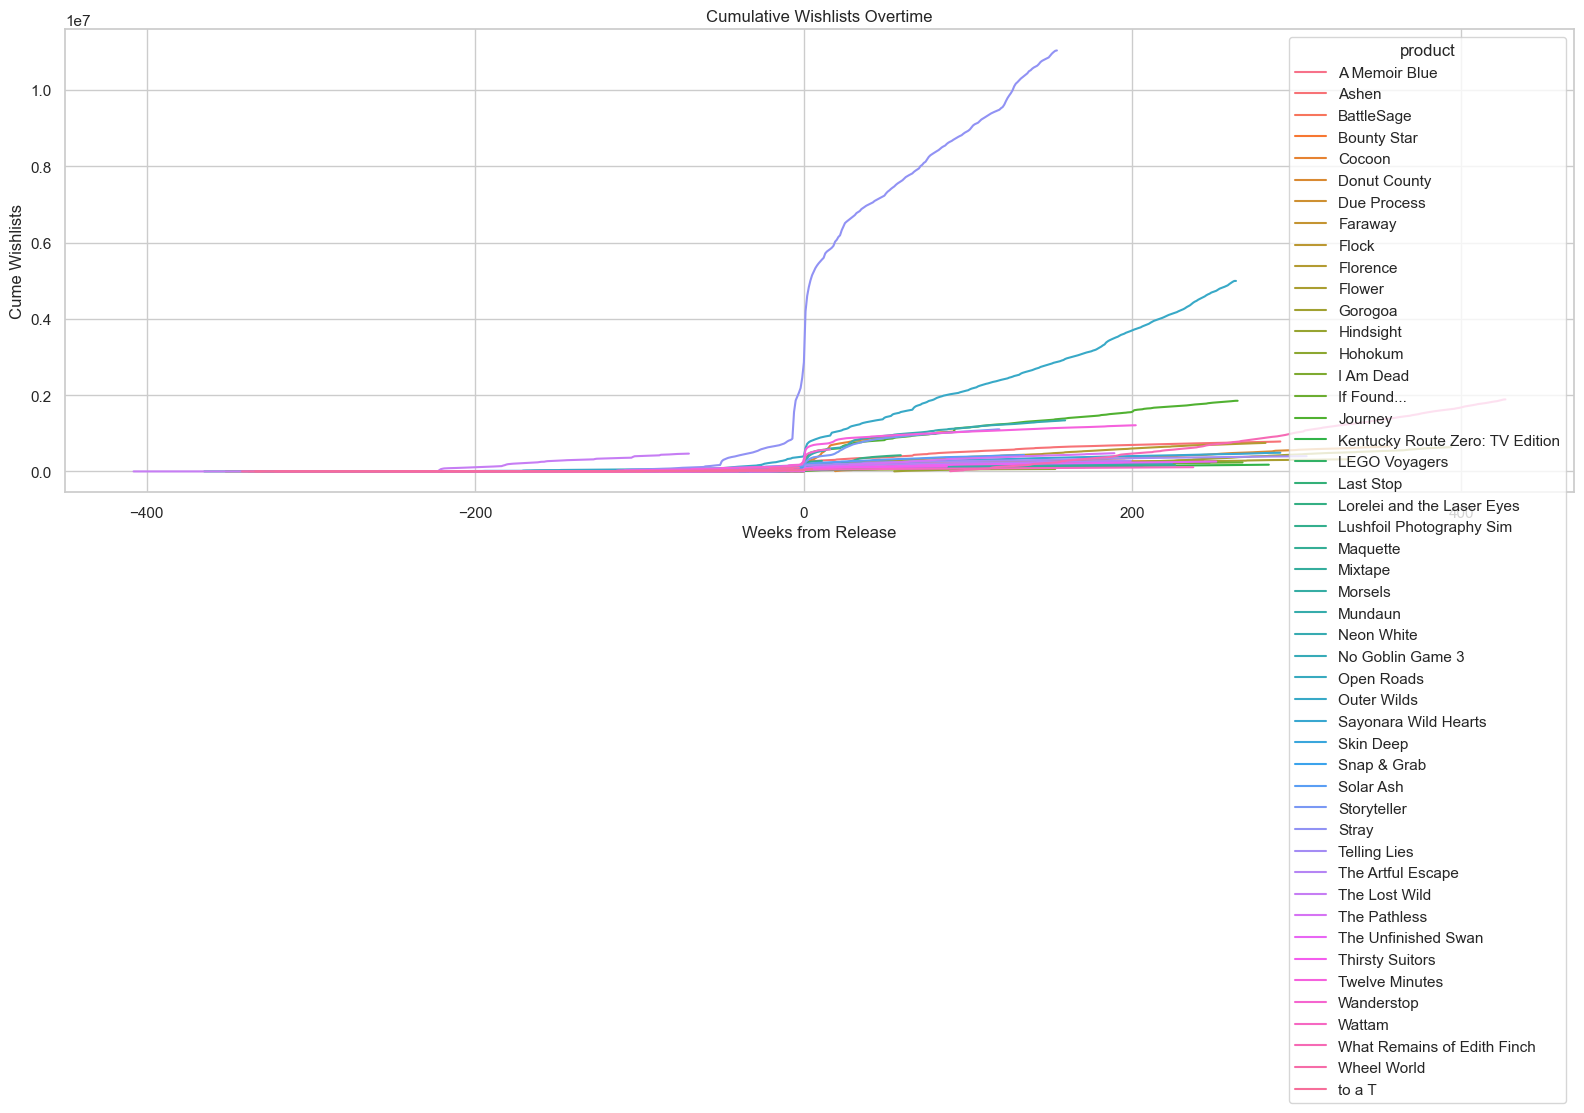

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=df, x="Weeks_from_Release", y="cumulative_additions", hue='product')

# Adding titles and labels
plt.title("Cumulative Wishlists Overtime")
plt.xlabel("Weeks from Release")
plt.ylabel("Cume Wishlists")

# Show the plot
plt.tight_layout()
plt.show()

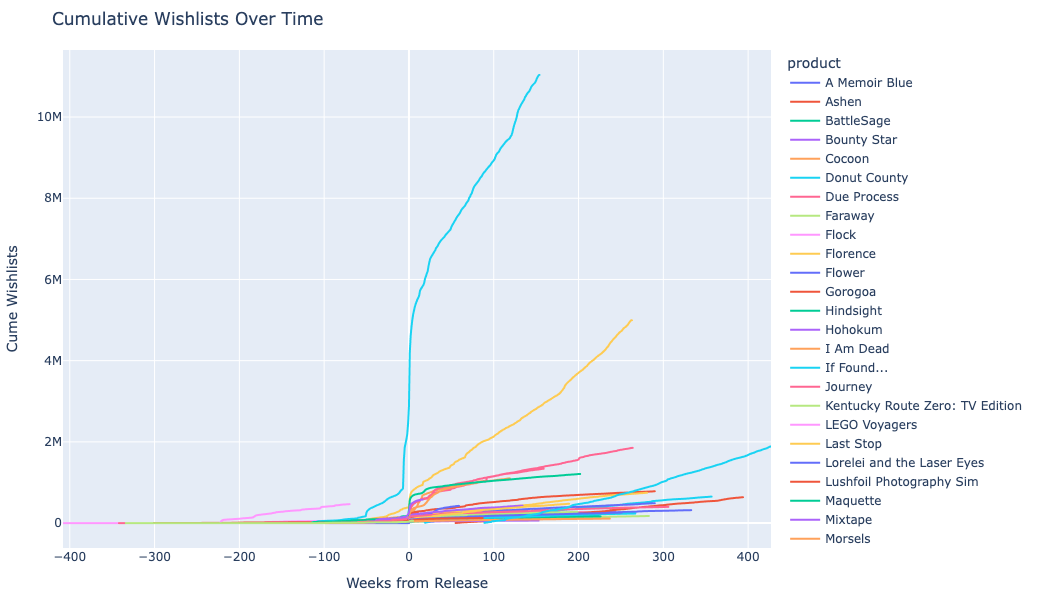

In [42]:
import plotly.express as px

# Create the interactive line plot
fig = px.line(df, 
              x="Weeks_from_Release", 
              y="cumulative_additions", 
              color='product',
              title="Cumulative Wishlists Over Time",
              labels={
                  "Weeks_from_Release": "Weeks from Release",
                  "cumulative_additions": "Cume Wishlists"
              })

# Update the layout for better aesthetics
fig.update_layout(
    autosize=True,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20),
    hovermode='closest'
)

# Save as HTML
fig.write_html("docs/cumulative_wishlists_overtime.html")

# Show the interactive plot
fig.show()

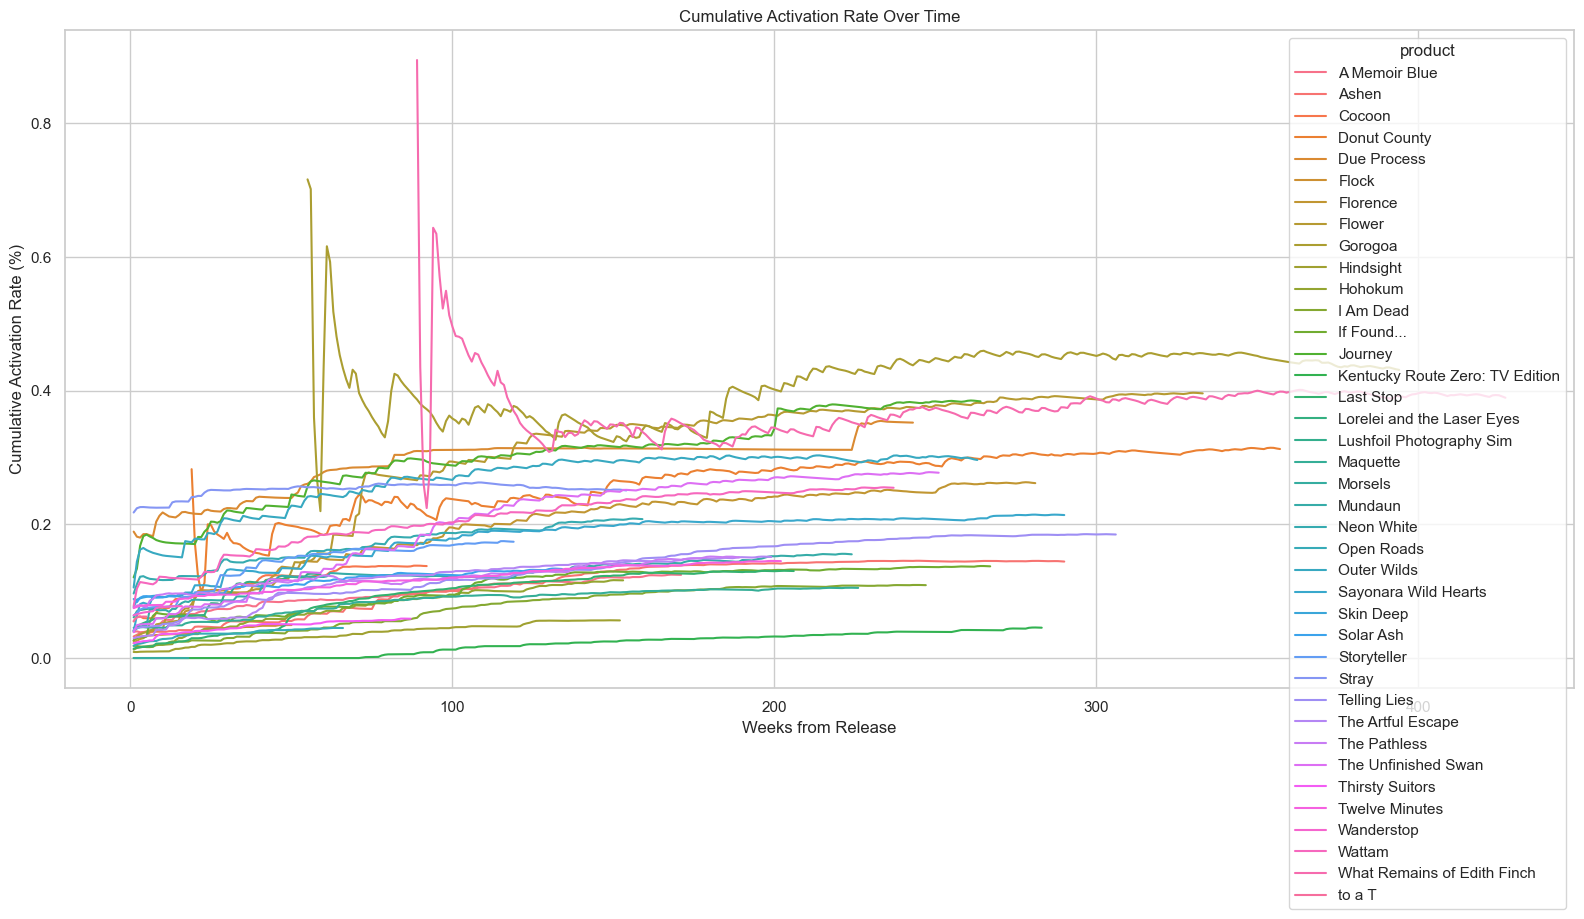

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="cumulative_act_rate", hue='product')


# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

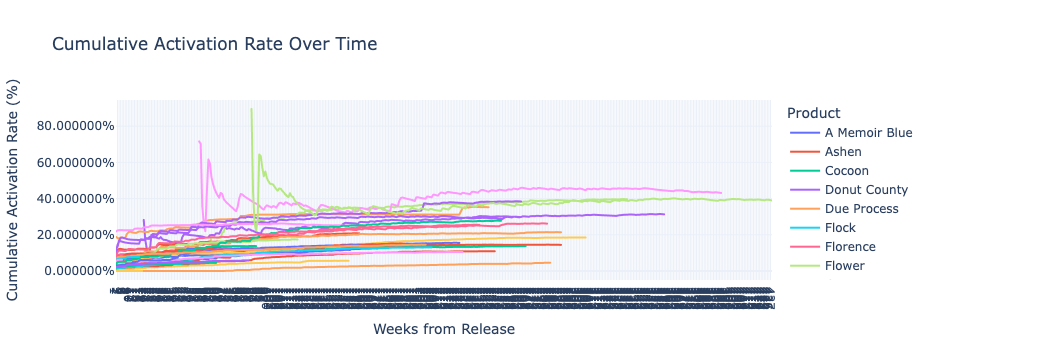

In [44]:
import plotly.express as px

# Create the Plotly line plot
fig = px.line(
    act_rate_df,
    x="Weeks_from_Release",
    y="cumulative_act_rate",
    color='product',
    title="Cumulative Activation Rate Over Time",
    labels={
        "Weeks_from_Release": "Weeks from Release",
        "cumulative_act_rate": "Cumulative Activation Rate (%)"
    },
    template='plotly_white'
)

# Improve layout for readability
fig.update_layout(
    legend_title_text='Product',
    xaxis=dict(tickmode='linear'),
    yaxis_tickformat='%'
)

# Display the plot
fig.show()

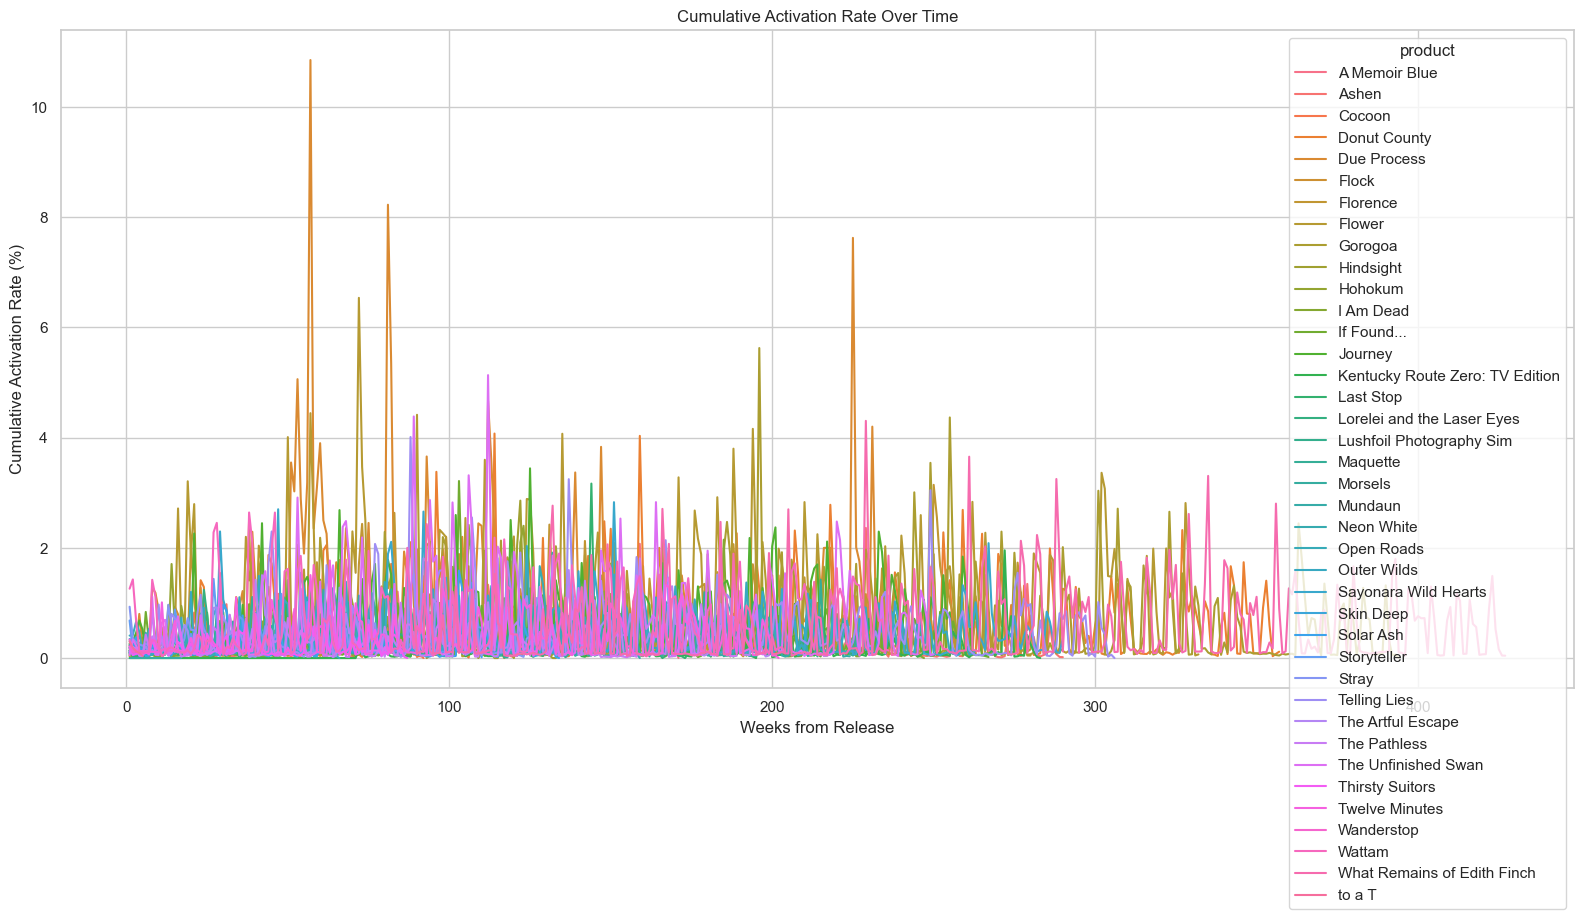

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="act_rate", hue='product')

#plt.ylim(1,25)

# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

In [46]:
INTERACTIVE_HISTORICAL_TABLE = df.query("Weeks_from_Release <=0").sort_values(by='Weeks_from_Release').drop_duplicates(subset="product", keep='last')

In [62]:
INTERACTIVE_HISTORICAL_TABLE.to_clipboard()

In [48]:
INTERACTIVE_HISTORICAL_TABLE

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
11875,The Lost Wild,-70.0,181,466239,1,0.000000,0.000002
8473,No Goblin Game 3,-32.0,62,9313,0,0.000000,0.000000
9837,Snap & Grab,-32.0,5,500,0,0.000000,0.000000
2404,Faraway,-26.0,5,5408,0,0.000000,0.000000
7450,Mixtape,-26.0,319,150312,0,0.000000,0.000000
1356,Bounty Star,-14.0,33,55194,1,0.000000,0.000018
5752,LEGO Voyagers,-13.0,175,11266,0,0.000000,0.000000
14592,Wheel World,-3.0,404,99708,0,0.000000,0.000000
12303,The Unfinished Swan,0.0,0,0,0,NaN,NaN
10043,Solar Ash,0.0,2114,132060,11494,0.006231,0.090536
